# Driving School Installs Prediction (SARIMA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from utils import check_stationarity, plot_decomposition

warnings.filterwarnings("ignore")

## Hyperparameters & Config

In [2]:
DATA_CSV_FILE = "../../../data/ds_data_clean.csv"
TARGET_COL = "Daily User Installs"
TRAIN_RATIO = 0.8
SEASONAL_PERIOD = 7  # Weekly seasonality

## Loading Data

In [3]:
df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

series = df[TARGET_COL]
series.head()

Date
2019-09-02    2
2019-09-03    1
2019-09-04    2
2019-09-05    3
2019-09-06    6
Name: Daily User Installs, dtype: int64

## Stationarity Check

In [4]:
check_stationarity(series, title=TARGET_COL)

--- Stationarity Tests for Daily User Installs ---
ADF Statistic: -3.9122
ADF p-value: 0.0019
ADF Critical Values:
   1%: -3.4332
   5%: -2.8628
   10%: -2.5674
KPSS Statistic: 0.5268
KPSS p-value: 0.0356
KPSS Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: The series is likely non-stationary.


## Seasonal Decomposition

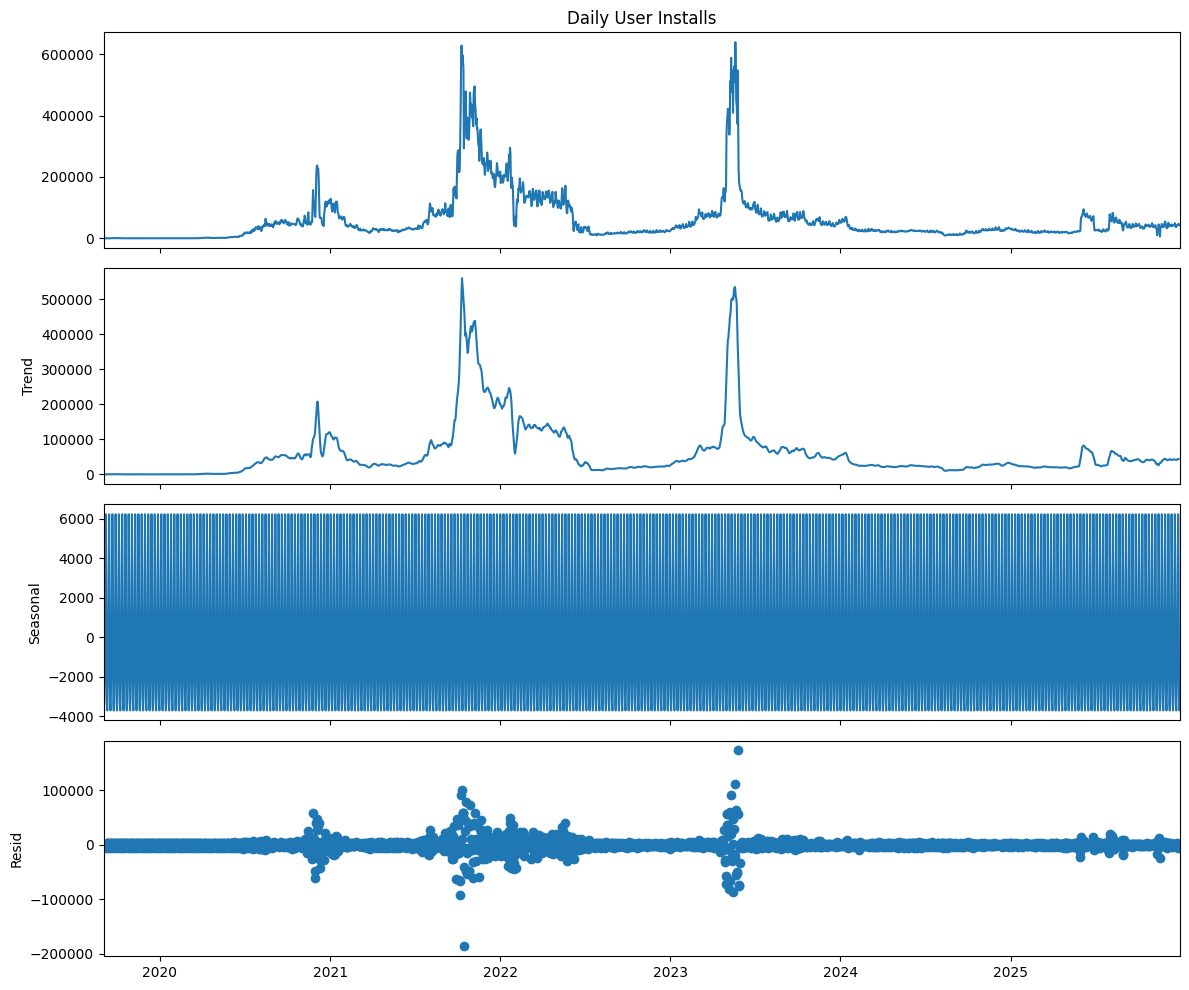

In [5]:
plot_decomposition(series, period=SEASONAL_PERIOD)

## Train/Test Split

In [6]:
train_size = int(len(series) * TRAIN_RATIO)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print(f"Train size: {len(train)}")
print(f"Test size:  {len(test)}")

Train size: 1850
Test size:  463


## Auto-ARIMA to Find Optimal SARIMA Parameters (p, d, q) x (P, D, Q, s)

In [7]:
model_auto = auto_arima(
    train,
    seasonal=True,
    m=SEASONAL_PERIOD,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.86 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=41581.263, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=41553.558, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=41558.080, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=41579.264, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=41583.202, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=41545.079, Time=0.17 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=41545.434, Time=0.52 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=41505.701, Time=0.49 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=41558.033, Time=0.09 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=41504.265, Time=0.86 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=41547.072, Time=0.17 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=41508.411, Time=1.07 sec
 ARIMA(0,1,0)(1,0,2)[7] intercept   : AIC=41502.493, Time=0.68 sec
 ARIMA(0,1,0)(0,0,2)[7] i

## Fit Final SARIMA Model

In [8]:
p, d, q = model_auto.order
P, D, Q, s = model_auto.seasonal_order

print(f"Fitting SARIMA({p},{d},{q})x({P},{D},{Q},{s})")

model = SARIMAX(
    train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)
print(model_fit.summary())

Fitting SARIMA(1,1,1)x(1,0,2,7)
                                       SARIMAX Results                                        
Dep. Variable:                    Daily User Installs   No. Observations:                 1850
Model:             SARIMAX(1, 1, 1)x(1, 0, [1, 2], 7)   Log Likelihood              -20564.243
Date:                                Mon, 30 Mar 2026   AIC                          41140.487
Time:                                        16:37:53   BIC                          41173.569
Sample:                                    09-02-2019   HQIC                         41152.688
                                         - 09-24-2024                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9667      0.002    391.454      0

## Forecasting & Evaluation

------------------------------
SARIMA EVALUATION RESULTS
------------------------------
RMSE: 28000.08 installs
MAE:  25186.43 installs
------------------------------


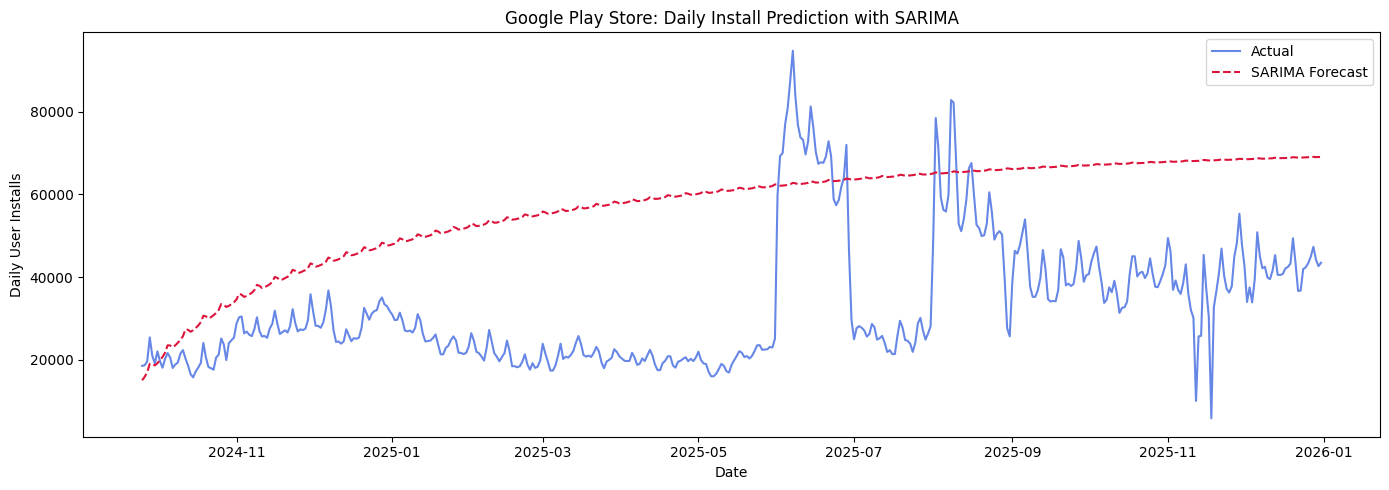

In [9]:
forecast = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("-" * 30)
print("SARIMA EVALUATION RESULTS")
print("-" * 30)
print(f"RMSE: {rmse:.2f} installs")
print(f"MAE:  {mae:.2f} installs")
print("-" * 30)

plt.figure(figsize=(14, 5))
# plt.plot(train.index, train, label="Train", color="gray", alpha=0.5)
plt.plot(test.index, test, label="Actual", color="royalblue", alpha=0.8)
plt.plot(test.index, forecast, label="SARIMA Forecast", color="crimson", linestyle="--")
plt.title("Google Play Store: Daily Install Prediction with SARIMA")
plt.xlabel("Date")
plt.ylabel("Daily User Installs")
plt.legend()
plt.tight_layout()
plt.show()

## Residual Analysis

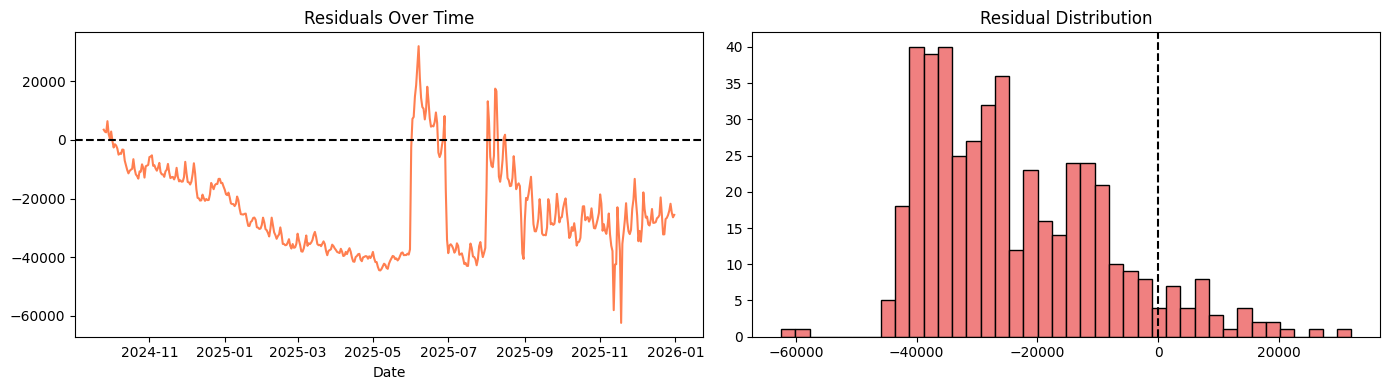

Mean Residual: -23709.15
Std Residual:  14911.78


In [10]:
residuals = pd.Series(test.values - forecast.values, index=test.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals, color="coral")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Residuals Over Time")
axes[0].set_xlabel("Date")

axes[1].hist(residuals, bins=40, color="lightcoral", edgecolor="black")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std Residual:  {residuals.std():.2f}")

## Model Diagnostics

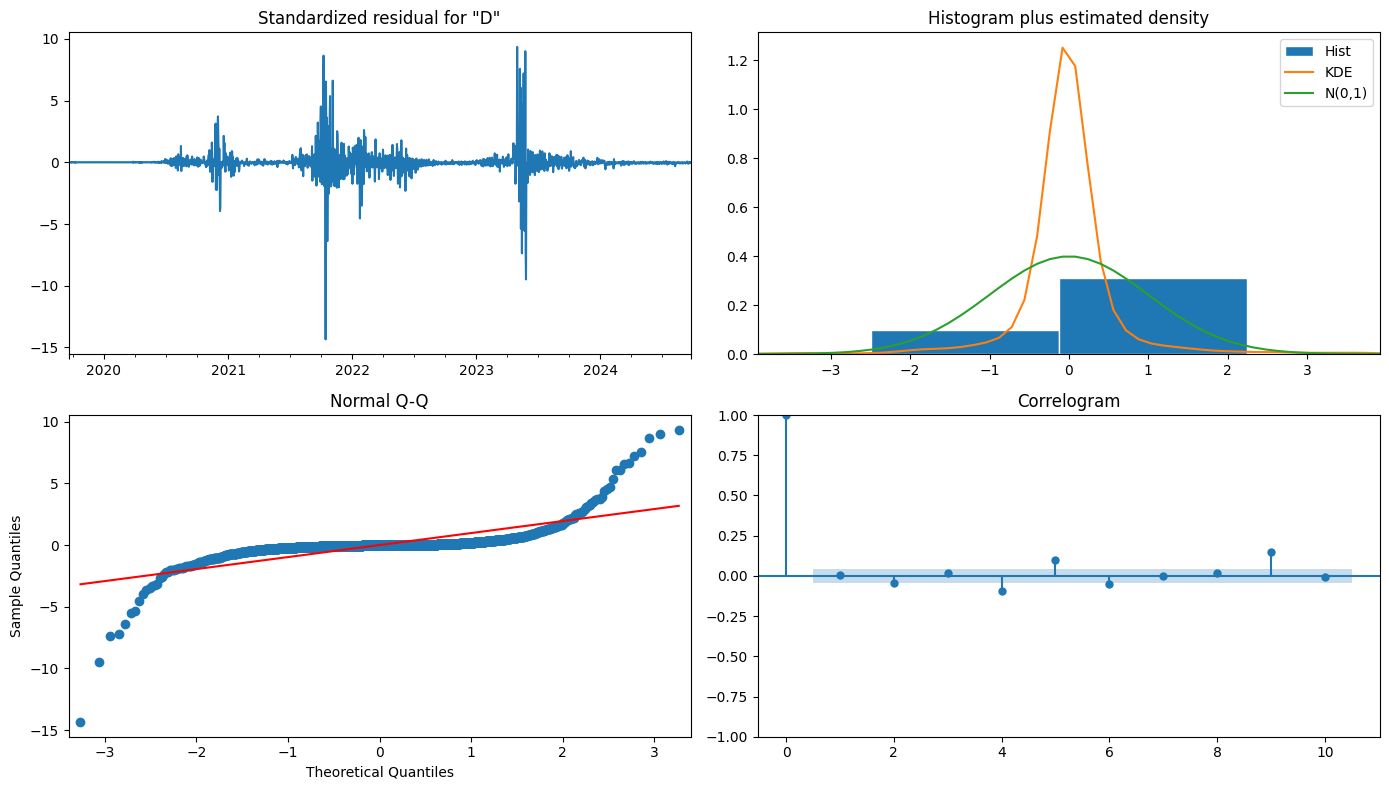

In [11]:
model_fit.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()